# 01 — EDA and Data Quality

Loading, initial EDA, missing-value analysis, deduplication, anomaly filtering.


In [1]:
# ── Find project root automatically ─────────────────────────────────────────
import os, pathlib, sys, warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

# Find thesis_package root (where requirements.txt + src/ live)
_CWD = pathlib.Path(os.getcwd()).resolve()
_ROOT = _CWD
for _ in range(6):
    if (_ROOT / 'requirements.txt').exists() and (_ROOT / 'src').exists():
        break
    _ROOT = _ROOT.parent
else:
    raise RuntimeError(f'thesis_package root not found. CWD={_CWD}')

os.chdir(_ROOT)
sys.path.insert(0, str(_ROOT))
_DATA_DIR = _ROOT / 'notebooks' / 'notebooks_data'
_DATA_DIR.mkdir(parents=True, exist_ok=True)
print(f'✅ Root: {_ROOT}')
print(f'✅ Data dir: {_DATA_DIR}')


✅ Root: /Users/veronikacharnosh/Desktop/Thesis/thesis vs code/thesis_package
✅ Data dir: /Users/veronikacharnosh/Desktop/Thesis/thesis vs code/thesis_package/notebooks/notebooks_data


# Real Estate Price Forecasting — bachelor's thesis (UCU)
### Kyiv and Lviv, 2023–2026: rental and sale

**Topic:** price forecasting accounting for macro indicators and external safety factors
**Data source:** LUN marketplace (aggregated CSV in the repository)

---

## Notebook logic (system analysis + DS pipeline)

| Step | Section |
|------|---------|
| **A** | Imports, path config, raw-data loading |
| **B** | Initial overview (EDA) across 4 segments |
| **C** | Missing values, duplicates, deduplication, physical anomaly filter |
| **D** | Feature engineering (time, area, autonomy, interactions) |
| **E** | External data: macro (NBU, FX, indices), geo (OSM), alerts |
| **F** | Merge `df_feat`, leakage-free preprocessing (categories fit on train) |
| **G** | Temporal split: train ≤ 2025-04-30, test ≥ 2025-10-01 |
| **H** | Feature validation (correlations, MI, target) |
| **I** | Model training: Ridge, Random Forest, XGBoost, LightGBM, MLP |
| **J** | Metrics, feature importance, SHAP (interpretation) |
| **K** | Artefact saving (`parquet`) for batch scoring |

Run cells **top-to-bottom** after Restart Kernel.


## 1. Imports and data loading


**Dependencies:** `pandas`, `numpy`, `scipy`, `scikit-learn`, `xgboost`, `matplotlib`, `seaborn`, `openpyxl`, `requests`; for Parquet — `pyarrow`; for SHAP — `shap`.

Install (local / venv): `pip install pandas numpy scipy scikit-learn xgboost matplotlib seaborn openpyxl requests pyarrow shap`


In [2]:
# ─── Core imports (consolidated — Option 1) ──────────────────────────────────
import os, io, re, time, warnings, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import seaborn as sns

from scipy import stats
from scipy.stats import spearmanr, mannwhitneyu

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import mutual_info_regression
from sklearn.experimental import enable_iterative_imputer  # must precede IterativeImputer import
from sklearn.impute import SimpleImputer, IterativeImputer
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    from xgboost import XGBRegressor
except ImportError:
    XGBRegressor = None

try:
    from category_encoders import TargetEncoder
except ImportError:
    TargetEncoder = None
try:
    from lightgbm import LGBMRegressor
except ImportError:
    LGBMRegressor = None
    TargetEncoder = None

import requests

warnings.filterwarnings('ignore')

# ─── Temporal split — SINGLE SOURCE OF TRUTH (70/15/15) ──────────────────────
# Train: 2023-05 → 2025-04-30       (~73%)
# GAP:   2025-05-01 → 2025-05-31    (dropped, breaks listing auto-correlation)
# Val:   2025-06-01 → 2025-08-31    (~9%, hyperparam tuning, early stopping)
# GAP:   2025-09-01 → 2025-09-30    (dropped)
# Test:  2025-10-01 → 2026-01-25    (~12%, final eval only, touched once)
TRAIN_END   = pd.Timestamp('2025-04-30')
GAP1_START  = pd.Timestamp('2025-05-01')
GAP1_END    = pd.Timestamp('2025-05-31')
VAL_START   = pd.Timestamp('2025-06-01')
VAL_END     = pd.Timestamp('2025-08-31')
GAP2_START  = pd.Timestamp('2025-09-01')
GAP2_END    = pd.Timestamp('2025-09-30')
TEST_START  = pd.Timestamp('2025-10-01')

# Legacy alias for compatibility with code that hasn't migrated yet
TRAIN_CUTOFF = TRAIN_END

WAR_START    = pd.Timestamp('2022-02-24')
RANDOM_STATE = 42


def split_mask(df, kind):
    """kind ∈ {'train','val','test'} → boolean mask on df['date']."""
    d = pd.to_datetime(df['date'], errors='coerce')
    if kind == 'train': return d <= TRAIN_END
    if kind == 'val':   return (d >= VAL_START)  & (d <= VAL_END)
    if kind == 'test':  return d >= TEST_START
    raise ValueError(kind)


def drop_gaps(df):
    """Drop rows falling inside GAP1 (May 2025) or GAP2 (Sep 2025)."""
    d = pd.to_datetime(df['date'], errors='coerce')
    m1 = (d >= GAP1_START) & (d <= GAP1_END)
    m2 = (d >= GAP2_START) & (d <= GAP2_END)
    return df[~(m1 | m2)].copy()


print('✅ Imports + config loaded')
print(f'   Train: ≤ {TRAIN_END.date()}')
print(f'   Val:   {VAL_START.date()} → {VAL_END.date()}')
print(f'   Test:  ≥ {TEST_START.date()}')
print(f'   Gaps:  {GAP1_START.date()}→{GAP1_END.date()}, {GAP2_START.date()}→{GAP2_END.date()}')


✅ Imports + config loaded
   Train: ≤ 2025-04-30
   Val:   2025-06-01 → 2025-08-31
   Test:  ≥ 2025-10-01
   Gaps:  2025-05-01→2025-05-31, 2025-09-01→2025-09-30


In [3]:

# Google Colab — mount drive
# from google.colab import drive
# drive.mount('/content/drive')

In [4]:
# CSV lives in thesis_package/data/
_csv_candidates = list((_ROOT / 'data').glob('*.csv'))
if not _csv_candidates:
    raise FileNotFoundError(f'CSV not found in {_ROOT}/data/ — copy unique_2023-05_2026-01_KL.csv there')
PATH = str(_csv_candidates[0])
print(f'Loading: {PATH}')

data = pd.read_csv(PATH, low_memory=False)
data['date'] = pd.to_datetime(data['date'])

print(f"Loaded: {len(data):,} rows × {data.shape[1]} columns")
print(f"Date range: {data['date'].min().date()} → {data['date'].max().date()}")
data.head(3)

Loading: /Users/veronikacharnosh/Desktop/Thesis/thesis vs code/thesis_package/data/unique_2023-05_2026-01_KL.csv
Loaded: 1,016,117 rows × 54 columns
Date range: 2023-05-25 → 2026-01-24


,page_id,date,contract_type,realty_type,region,city,district,microdistrict,street,house_number,...,autonomy_heat,autonomy_water,autonomy_net,autonomy_lift,is_babushka_renovation,pets_allowed_full,price_uah,price_usd,price_m2_uah,price_m2_usd
0,1.005998e+09,2025-02-24,Оренда,Квартира,Львівська,Львів,Галицький,NaN,NaN,NaN,...,no,no,no,no,unknown,unknown,29399.44,700.000000,489.99,11.67
1,1.006338e+09,2025-02-24,Оренда,Квартира,Київська,Київ,Подільський,Виноградар,просп. Правди,41д,...,no,no,yes,no,no,no,21000.00,500.009524,446.81,10.64
2,1.006733e+09,2025-02-24,Оренда,Квартира,Львівська,Львів,Сихівський,Новий Львів,вул. Тернопільська,NaN,...,no,no,no,no,no,unknown,25199.52,600.000000,458.17,10.91


## 2. Initial EDA — 4 segments
### Lviv — Rent | Kyiv — Rent | Lviv — Sale | Kyiv — Sale


In [5]:
data_rent = data[data['contract_type'] == "Оренда"]
data_rent

,page_id,date,contract_type,realty_type,region,city,district,microdistrict,street,house_number,...,autonomy_heat,autonomy_water,autonomy_net,autonomy_lift,is_babushka_renovation,pets_allowed_full,price_uah,price_usd,price_m2_uah,price_m2_usd
0,1.005998e+09,2025-02-24,Оренда,Квартира,Львівська,Львів,Галицький,NaN,NaN,NaN,...,no,no,no,no,unknown,unknown,29399.44,700.000000,489.99,11.67
1,1.006338e+09,2025-02-24,Оренда,Квартира,Київська,Київ,Подільський,Виноградар,просп. Правди,41д,...,no,no,yes,no,no,no,21000.00,500.009524,446.81,10.64
2,1.006733e+09,2025-02-24,Оренда,Квартира,Львівська,Львів,Сихівський,Новий Львів,вул. Тернопільська,NaN,...,no,no,no,no,no,unknown,25199.52,600.000000,458.17,10.91
3,2.509113e+09,2025-02-24,Оренда,Квартира,Київська,Київ,Печерський,Звіринець,вул. Болсуновська (Сергія Струтинського),2,...,no,no,no,no,no,unknown,125997.60,3000.000000,812.89,19.35
4,1.946032e+09,2025-02-24,Оренда,Квартира,Київська,Київ,Солом'янський,Солом'янка,вул. Шаповала (Механізаторів),2,...,unknown,unknown,unknown,unknown,no,unknown,167996.80,4000.000000,839.98,20.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1016108,NaN,2023-05-25,Оренда,Квартира,NaN,Львів,Залізничний,Левандівка,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,8500.00,227.000000,242.86,6.49
1016109,NaN,2023-05-25,Оренда,Квартира,NaN,Київ,Голосіївський,Феофанія,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,15000.00,400.000000,348.84,9.30
1016110,NaN,2023-05-25,Оренда,Квартира,NaN,Львів,Франківський,Наукова,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,17000.00,454.000000,242.86,6.49
1016112,NaN,2023-05-25,Оренда,Квартира,NaN,Львів,Галицький,Центр,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,16000.00,427.000000,290.91,7.76


In [6]:
data_sale = data[data['contract_type'] == "Продаж"]
data_sale

,page_id,date,contract_type,realty_type,region,city,district,microdistrict,street,house_number,...,autonomy_heat,autonomy_water,autonomy_net,autonomy_lift,is_babushka_renovation,pets_allowed_full,price_uah,price_usd,price_m2_uah,price_m2_usd
10992,1.000728e+09,2025-02-24,Продаж,Квартира,Київська,Київ,Голосіївський,Нова забудова,вул. Антоновича (Горького),44,...,unknown,unknown,unknown,unknown,unknown,unknown,18710643.60,445500.0,188996.40,4500.00
10993,1.000732e+09,2025-02-24,Продаж,Квартира,Київська,Київ,Печерський,Липки,вул. Круглоуніверситетська,18/2,...,unknown,unknown,unknown,unknown,unknown,unknown,25199520.00,600000.0,119429.00,2843.60
10994,1.000787e+09,2025-02-24,Продаж,Квартира,Київська,Київ,NaN,NaN,вул. Чернігівська,8а,...,unknown,unknown,unknown,unknown,unknown,unknown,3023942.40,72000.0,51080.11,1216.22
10995,1.000797e+09,2025-02-24,Продаж,Квартира,Київська,Київ,Дарницький,NaN,NaN,2,...,unknown,unknown,unknown,unknown,unknown,unknown,3401935.20,81000.0,46601.85,1109.59
10996,1.000804e+09,2025-02-24,Продаж,Квартира,Київська,Київ,Печерський,Нова забудова,вул. Предславинська,25,...,unknown,unknown,unknown,unknown,unknown,unknown,2893744.88,68900.0,53587.87,1275.93
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1016106,NaN,2023-05-25,Продаж,Квартира,NaN,Київ,Дніпровський,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1350000.00,36000.0,35526.32,947.37
1016111,NaN,2023-05-25,Продаж,Квартира,NaN,Київ,Дніпровський,Північно-Броварський (Комсомольський),NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1312500.00,35000.0,43750.00,1166.67
1016113,NaN,2023-05-25,Продаж,Квартира,NaN,Київ,Дарницький,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,3937500.00,105000.0,51809.21,1381.58
1016114,NaN,2023-05-25,Продаж,Квартира,NaN,Київ,Дарницький,Позняки,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2437500.00,65000.0,54166.67,1444.44


In [7]:
df_rent_lviv = data_rent[data_rent['city'] == "Львів"]
df_rent_lviv

,page_id,date,contract_type,realty_type,region,city,district,microdistrict,street,house_number,...,autonomy_heat,autonomy_water,autonomy_net,autonomy_lift,is_babushka_renovation,pets_allowed_full,price_uah,price_usd,price_m2_uah,price_m2_usd
0,1.005998e+09,2025-02-24,Оренда,Квартира,Львівська,Львів,Галицький,NaN,NaN,NaN,...,no,no,no,no,unknown,unknown,29399.44,700.00000,489.99,11.67
2,1.006733e+09,2025-02-24,Оренда,Квартира,Львівська,Львів,Сихівський,Новий Львів,вул. Тернопільська,NaN,...,no,no,no,no,no,unknown,25199.52,600.00000,458.17,10.91
10,1.020714e+09,2025-02-24,Оренда,Квартира,Львівська,Львів,Галицький,Центр,вул. Сніжна,NaN,...,yes,yes,yes,yes,no,yes,20999.60,500.00000,349.99,8.33
14,2.475601e+09,2025-02-24,Оренда,Квартира,Львівська,Львів,Шевченківський,Голоско Мале,вул. Замарстинівська,55,...,unknown,unknown,unknown,unknown,no,no,20999.60,500.00000,499.99,11.90
22,1.051966e+09,2025-02-24,Оренда,Квартира,Львівська,Львів,Галицький,NaN,вул. Городоцька,NaN,...,no,no,no,no,no,no,15000.00,357.14966,652.17,15.53
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1016101,NaN,2023-05-25,Оренда,Квартира,NaN,Львів,Шевченківський,Клепарів,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,24375.00,650.00000,270.83,7.22
1016108,NaN,2023-05-25,Оренда,Квартира,NaN,Львів,Залізничний,Левандівка,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,8500.00,227.00000,242.86,6.49
1016110,NaN,2023-05-25,Оренда,Квартира,NaN,Львів,Франківський,Наукова,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,17000.00,454.00000,242.86,6.49
1016112,NaN,2023-05-25,Оренда,Квартира,NaN,Львів,Галицький,Центр,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,16000.00,427.00000,290.91,7.76


In [8]:
df_rent_kyiv = data_rent[data_rent['city'] == "Київ"]
df_rent_kyiv

,page_id,date,contract_type,realty_type,region,city,district,microdistrict,street,house_number,...,autonomy_heat,autonomy_water,autonomy_net,autonomy_lift,is_babushka_renovation,pets_allowed_full,price_uah,price_usd,price_m2_uah,price_m2_usd
1,1.006338e+09,2025-02-24,Оренда,Квартира,Київська,Київ,Подільський,Виноградар,просп. Правди,41д,...,no,no,yes,no,no,no,21000.0,500.009524,446.81,10.64
3,2.509113e+09,2025-02-24,Оренда,Квартира,Київська,Київ,Печерський,Звіринець,вул. Болсуновська (Сергія Струтинського),2,...,no,no,no,no,no,unknown,125997.6,3000.000000,812.89,19.35
4,1.946032e+09,2025-02-24,Оренда,Квартира,Київська,Київ,Солом'янський,Солом'янка,вул. Шаповала (Механізаторів),2,...,unknown,unknown,unknown,unknown,no,unknown,167996.8,4000.000000,839.98,20.00
5,1.015577e+09,2025-02-24,Оренда,Квартира,Київська,Київ,Печерський,Нижній Печерськ,вул. Саперне Поле,14/55,...,unknown,unknown,unknown,unknown,no,no,31499.4,750.000000,594.33,14.15
6,1.017325e+09,2025-02-24,Оренда,Квартира,Київська,Київ,Дарницький,NaN,вул. Чернігівська,8,...,unknown,unknown,unknown,unknown,unknown,unknown,14900.0,354.768662,157.34,3.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1016099,NaN,2023-05-25,Оренда,Квартира,NaN,Київ,Деснянський,Троєщина,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,9000.0,240.000000,176.47,4.71
1016100,NaN,2023-05-25,Оренда,Квартира,NaN,Київ,Дарницький,Позняки,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,9000.0,240.000000,96.77,2.58
1016102,NaN,2023-05-25,Оренда,Квартира,NaN,Київ,Солом'янський,Шулявка,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,21000.0,561.000000,362.07,9.67
1016107,NaN,2023-05-25,Оренда,Квартира,NaN,Київ,Шевченківський,Історичний центр,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,18000.0,481.000000,327.27,8.75


In [9]:
df_sale_lviv = data_sale[data_sale['city'] == "Львів"]
df_sale_lviv

,page_id,date,contract_type,realty_type,region,city,district,microdistrict,street,house_number,...,autonomy_heat,autonomy_water,autonomy_net,autonomy_lift,is_babushka_renovation,pets_allowed_full,price_uah,price_usd,price_m2_uah,price_m2_usd
11019,2.031791e+09,2025-02-24,Продаж,Квартира,Львівська,Львів,NaN,NaN,NaN,19,...,unknown,unknown,unknown,unknown,unknown,unknown,2645949.6,63000.000000,56177.27,1337.58
11020,2.546380e+09,2025-02-24,Продаж,Квартира,Львівська,Львів,Шевченківський,Голоско Мале,вул. Під Голоском,1,...,unknown,unknown,unknown,unknown,unknown,unknown,2645949.6,63000.000000,56177.27,1337.58
11026,1.011804e+09,2025-02-24,Продаж,Квартира,Львівська,Львів,Залізничний,NaN,вул. Городоцька,NaN,...,no,no,no,no,unknown,unknown,2288956.4,54500.000000,50865.70,1211.11
11034,1.014166e+09,2025-02-24,Продаж,Квартира,Львівська,Львів,Залізничний,NaN,вул. Залізнична,NaN,...,no,no,no,no,unknown,unknown,3757068.0,89455.703918,52916.45,1259.94
11051,1.018307e+09,2025-02-24,Продаж,Квартира,Львівська,Львів,NaN,NaN,NaN,14,...,unknown,unknown,unknown,unknown,unknown,unknown,6299880.0,150000.000000,86299.73,2054.79
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1016056,NaN,2023-05-25,Продаж,Квартира,NaN,Львів,Франківський,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1950000.0,52000.000000,41401.27,1104.03
1016061,NaN,2023-05-25,Продаж,Квартира,NaN,Львів,Галицький,Центр,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2587500.0,69000.000000,64687.50,1725.00
1016067,NaN,2023-05-25,Продаж,Квартира,NaN,Львів,Шевченківський,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,3637500.0,97000.000000,49155.41,1310.81
1016075,NaN,2023-05-25,Продаж,Квартира,NaN,Львів,Шевченківський,Замарстинів,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2205000.0,58800.000000,28573.28,761.95


In [10]:
df_sale_kyiv = data_sale[data_sale['city'] == "Київ"]
df_sale_kyiv

,page_id,date,contract_type,realty_type,region,city,district,microdistrict,street,house_number,...,autonomy_heat,autonomy_water,autonomy_net,autonomy_lift,is_babushka_renovation,pets_allowed_full,price_uah,price_usd,price_m2_uah,price_m2_usd
10992,1.000728e+09,2025-02-24,Продаж,Квартира,Київська,Київ,Голосіївський,Нова забудова,вул. Антоновича (Горького),44,...,unknown,unknown,unknown,unknown,unknown,unknown,18710643.60,445500.0,188996.40,4500.00
10993,1.000732e+09,2025-02-24,Продаж,Квартира,Київська,Київ,Печерський,Липки,вул. Круглоуніверситетська,18/2,...,unknown,unknown,unknown,unknown,unknown,unknown,25199520.00,600000.0,119429.00,2843.60
10994,1.000787e+09,2025-02-24,Продаж,Квартира,Київська,Київ,NaN,NaN,вул. Чернігівська,8а,...,unknown,unknown,unknown,unknown,unknown,unknown,3023942.40,72000.0,51080.11,1216.22
10995,1.000797e+09,2025-02-24,Продаж,Квартира,Київська,Київ,Дарницький,NaN,NaN,2,...,unknown,unknown,unknown,unknown,unknown,unknown,3401935.20,81000.0,46601.85,1109.59
10996,1.000804e+09,2025-02-24,Продаж,Квартира,Київська,Київ,Печерський,Нова забудова,вул. Предславинська,25,...,unknown,unknown,unknown,unknown,unknown,unknown,2893744.88,68900.0,53587.87,1275.93
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1016106,NaN,2023-05-25,Продаж,Квартира,NaN,Київ,Дніпровський,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1350000.00,36000.0,35526.32,947.37
1016111,NaN,2023-05-25,Продаж,Квартира,NaN,Київ,Дніпровський,Північно-Броварський (Комсомольський),NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1312500.00,35000.0,43750.00,1166.67
1016113,NaN,2023-05-25,Продаж,Квартира,NaN,Київ,Дарницький,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,3937500.00,105000.0,51809.21,1381.58
1016114,NaN,2023-05-25,Продаж,Квартира,NaN,Київ,Дарницький,Позняки,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2437500.00,65000.0,54166.67,1444.44


In [11]:
# ── Helper structure for all EDA cells ─────────────────────
SEGS = [
    ('Львів', 'Оренда', df_rent_lviv),
    ('Київ',  'Оренда', df_rent_kyiv),
    ('Львів', 'Продаж', df_sale_lviv),
    ('Київ',  'Продаж', df_sale_kyiv),
]

SEG_COLORS = ['#4e79a7', '#f28e2b', '#59a14f', '#e15759']

def best_price_col(ctype, df):
    """Return the first available price column"""
    candidates = (
        ['price_m2_uah', 'price_uah']
        if ctype == 'Оренда'
        else ['price_m2_usd', 'price_m2_uah', 'price_usd']
    )
    for col in candidates:
        if col in df.columns and df[col].notna().sum() > 50:
            return col
    return None

# ── Table: size of each segment ───────────────────────────
print("=" * 55)
print(f"{'Segment':<25} {'Rows':>10} {'Price column':>18}")
print("=" * 55)
for city, ctype, df_s in SEGS:
    col = best_price_col(ctype, df_s)
    filled = df_s[col].notna().sum() if col else 0
    print(f"  {city} — {ctype:<12}  {len(df_s):>9,}  {col or 'N/A':>18}  ({filled:,} filled)")
print("=" * 55)


Segment                         Rows       Price column
  Львів — Оренда          133,766        price_m2_uah  (127,887 filled)
  Київ — Оренда          199,152        price_m2_uah  (199,150 filled)
  Львів — Продаж          153,500        price_m2_usd  (151,075 filled)
  Київ — Продаж          529,699        price_m2_usd  (529,695 filled)


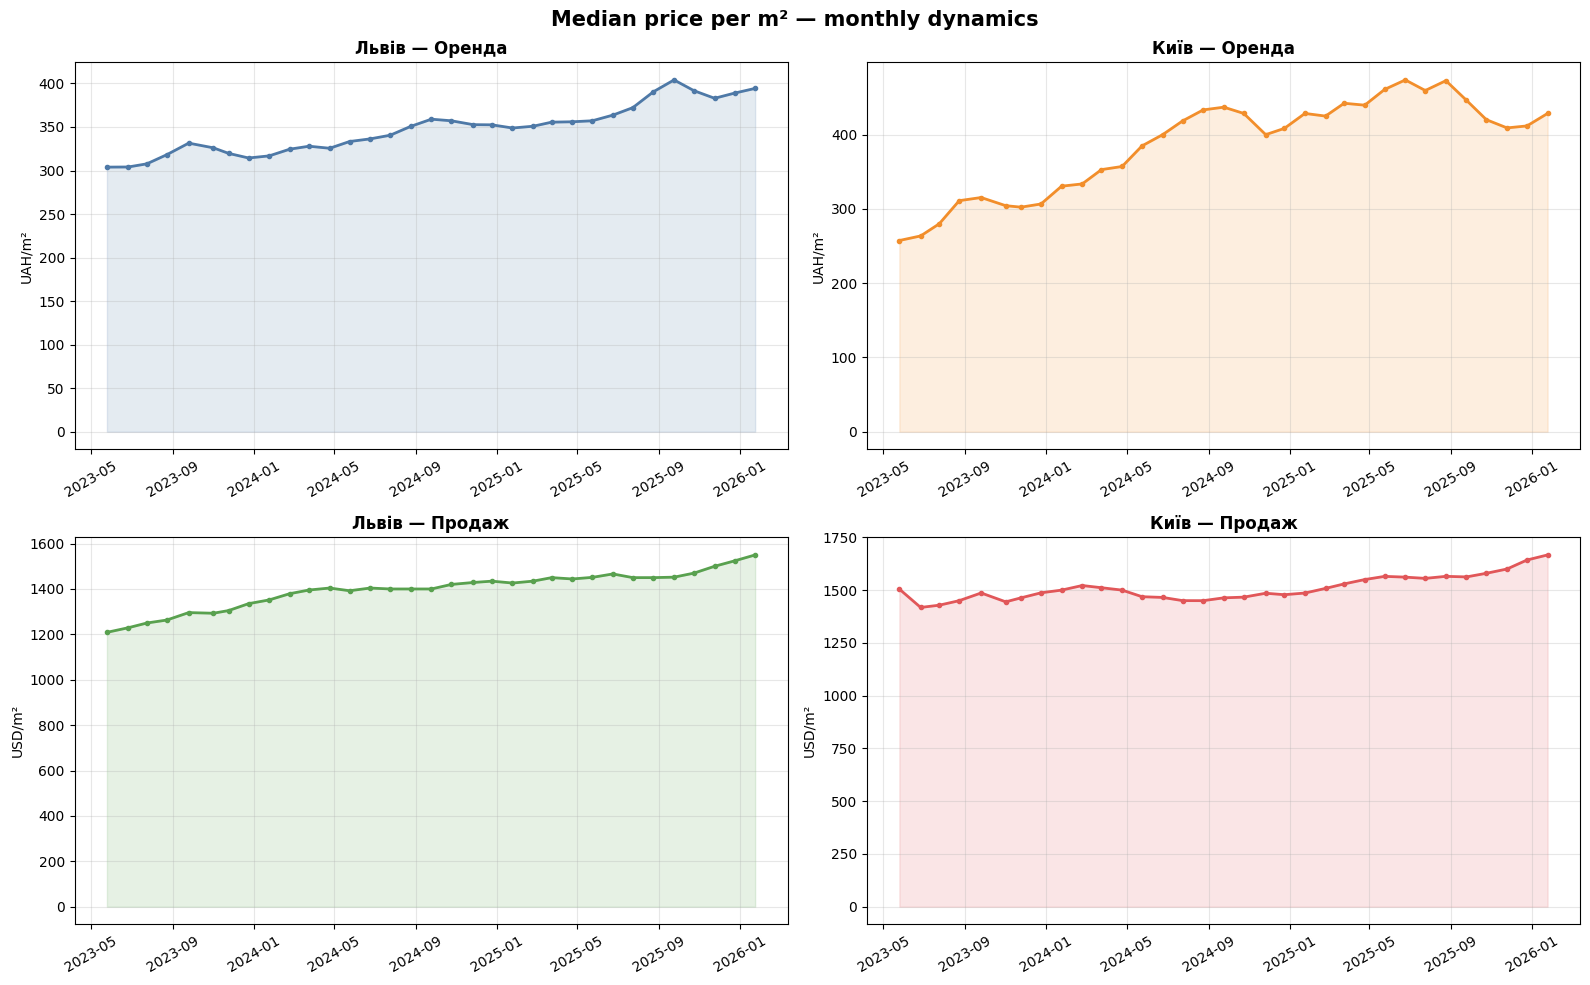

In [12]:
# ── Median price per m² — monthly dynamics (4 segments) ──
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=False)
fig.suptitle('Median price per m² — monthly dynamics', fontsize=15, fontweight='bold')
axes_flat = axes.flatten()

for i, (city, ctype, df_s) in enumerate(SEGS):
    ax = axes_flat[i]
    col = best_price_col(ctype, df_s)

    if col is None:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                transform=ax.transAxes, fontsize=12)
        ax.set_title(f'{city} — {ctype}', fontsize=12, fontweight='bold')
        continue

    df_tmp = df_s.copy()
    df_tmp['date'] = pd.to_datetime(df_tmp['date'], errors='coerce')
    df_tmp[col]    = pd.to_numeric(df_tmp[col], errors='coerce')
    monthly = df_tmp.groupby('date')[col].median().dropna()

    ax.plot(monthly.index, monthly.values, color=SEG_COLORS[i],
            linewidth=2, marker='o', markersize=3)
    ax.fill_between(monthly.index, monthly.values, alpha=0.15, color=SEG_COLORS[i])
    ax.set_title(f'{city} — {ctype}', fontsize=12, fontweight='bold')
    ylabel = 'UAH/m²' if 'uah' in col else 'USD/m²'
    ax.set_ylabel(ylabel, fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('price_dynamics_4seg.png', dpi=150)
plt.show()


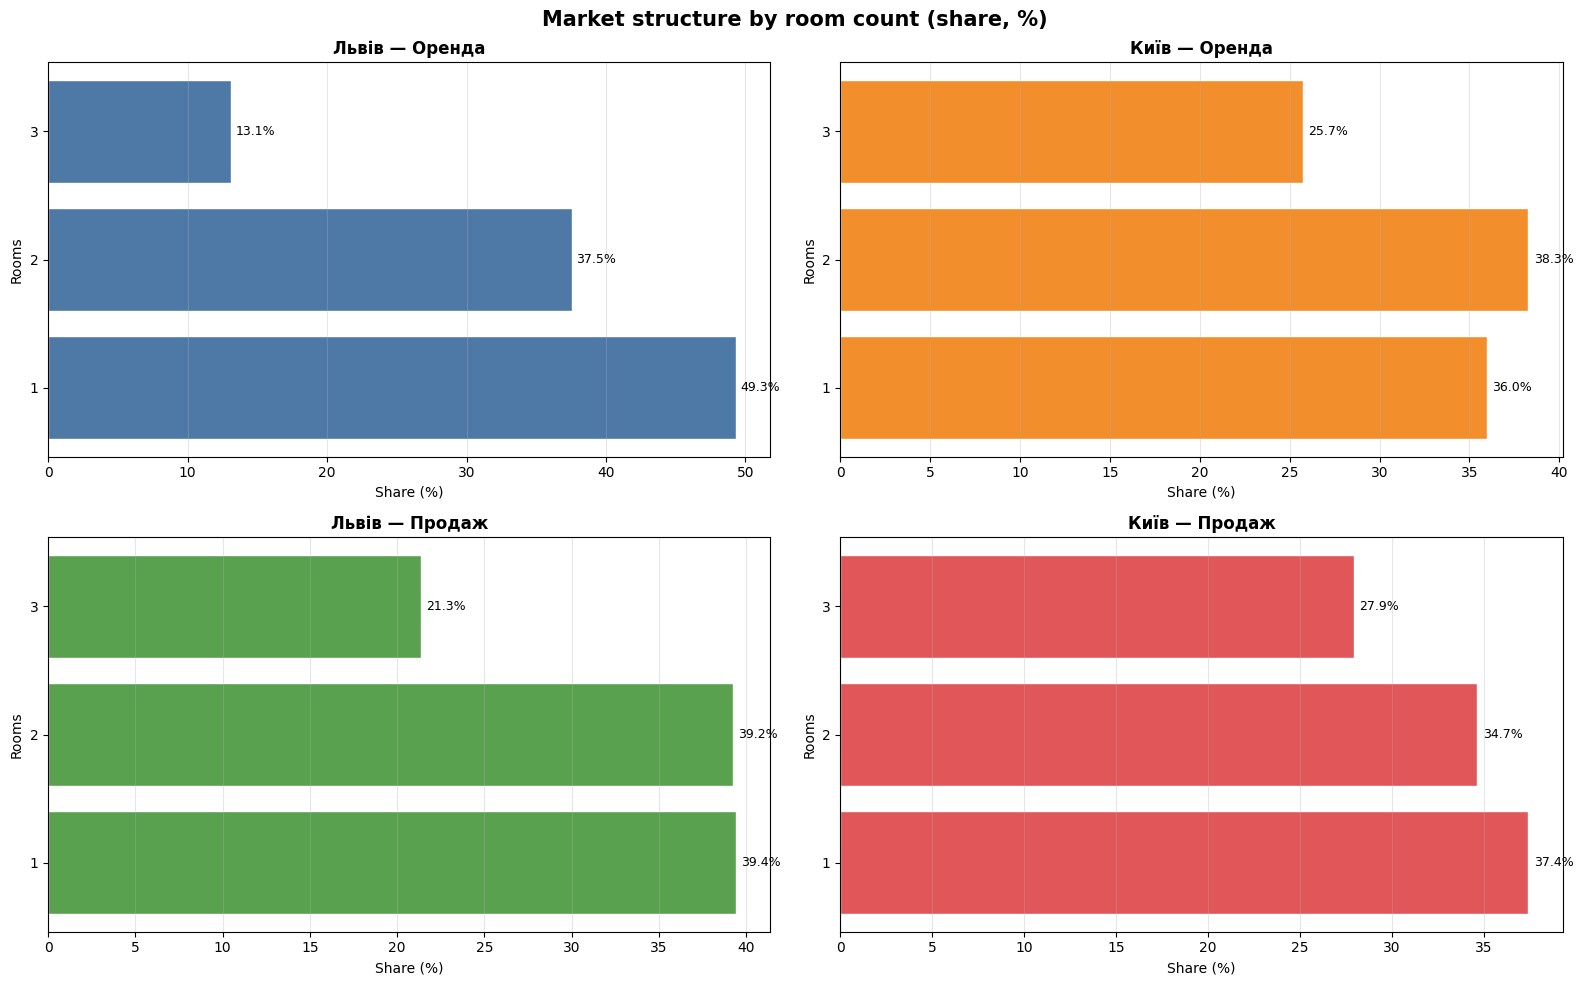

In [13]:
# ── Market structure by room count, % per segment (4 segments) ──
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Market structure by room count (share, %)', fontsize=15, fontweight='bold')
axes_flat = axes.flatten()

for i, (city, ctype, df_s) in enumerate(SEGS):
    ax = axes_flat[i]
    rc = (df_s['room_count']
          .dropna()
          .astype(int)
          .value_counts(normalize=True)
          .sort_index()
          .head(8) * 100)

    bars = ax.barh([str(x) for x in rc.index], rc.values,
                   color=SEG_COLORS[i], edgecolor='white')
    ax.set_title(f'{city} — {ctype}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Share (%)', fontsize=10)
    ax.set_ylabel('Rooms', fontsize=10)
    ax.grid(True, axis='x', alpha=0.3)
    for bar in bars:
        w = bar.get_width()
        ax.text(w + 0.3, bar.get_y() + bar.get_height() / 2,
                f'{w:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('room_share_4seg.png', dpi=150)
plt.show()


In [14]:
# ── Summary table: price by room count (4 segments) ────────
print("=" * 70)
print("MEDIAN PRICE PER M² BY ROOM COUNT")
print("=" * 70)

for city, ctype, df_s in SEGS:
    col = best_price_col(ctype, df_s)
    if col is None:
        print(f"\n{city} — {ctype}: no data")
        continue

    df_tmp = df_s.copy()
    df_tmp['room_count'] = pd.to_numeric(df_tmp['room_count'], errors='coerce')
    df_tmp[col] = pd.to_numeric(df_tmp[col], errors='coerce')
    df_tmp = df_tmp[df_tmp['room_count'].between(1, 6)]

    # ⚠️ Do NOT call it 'stats' — shadows scipy.stats for the rest of the session
    room_stats = df_tmp.groupby('room_count')[col].agg(['median', 'count'])
    room_stats.index = room_stats.index.astype(int)

    unit = 'UAH/m²' if 'uah' in col else 'USD/m²'
    print(f"\n  {city} — {ctype}  [{unit}]")
    print(f"  {'Rooms':<10} {'Median':>12} {'Count':>12}")
    print(f"  {'-'*36}")
    for rooms, row in room_stats.iterrows():
        print(f"  {rooms:<10} {row['median']:>12,.0f} {int(row['count']):>12,}")


MEDIAN PRICE PER M² BY ROOM COUNT

  Львів — Оренда  [UAH/m²]
  Rooms            Median        Count
  ------------------------------------
  1                   381       63,214
  2                   304       47,940
  3                   261       16,733

  Київ — Оренда  [UAH/m²]
  Rooms            Median        Count
  ------------------------------------
  1                   400       71,637
  2                   371       76,239
  3                   371       51,274

  Львів — Продаж  [USD/m²]
  Rooms            Median        Count
  ------------------------------------
  1                 1,453       59,675
  2                 1,364       59,341
  3                 1,301       32,059

  Київ — Продаж  [USD/m²]
  Rooms            Median        Count
  ------------------------------------
  1                 1,512      198,241
  2                 1,486      183,575
  3                 1,516      147,879


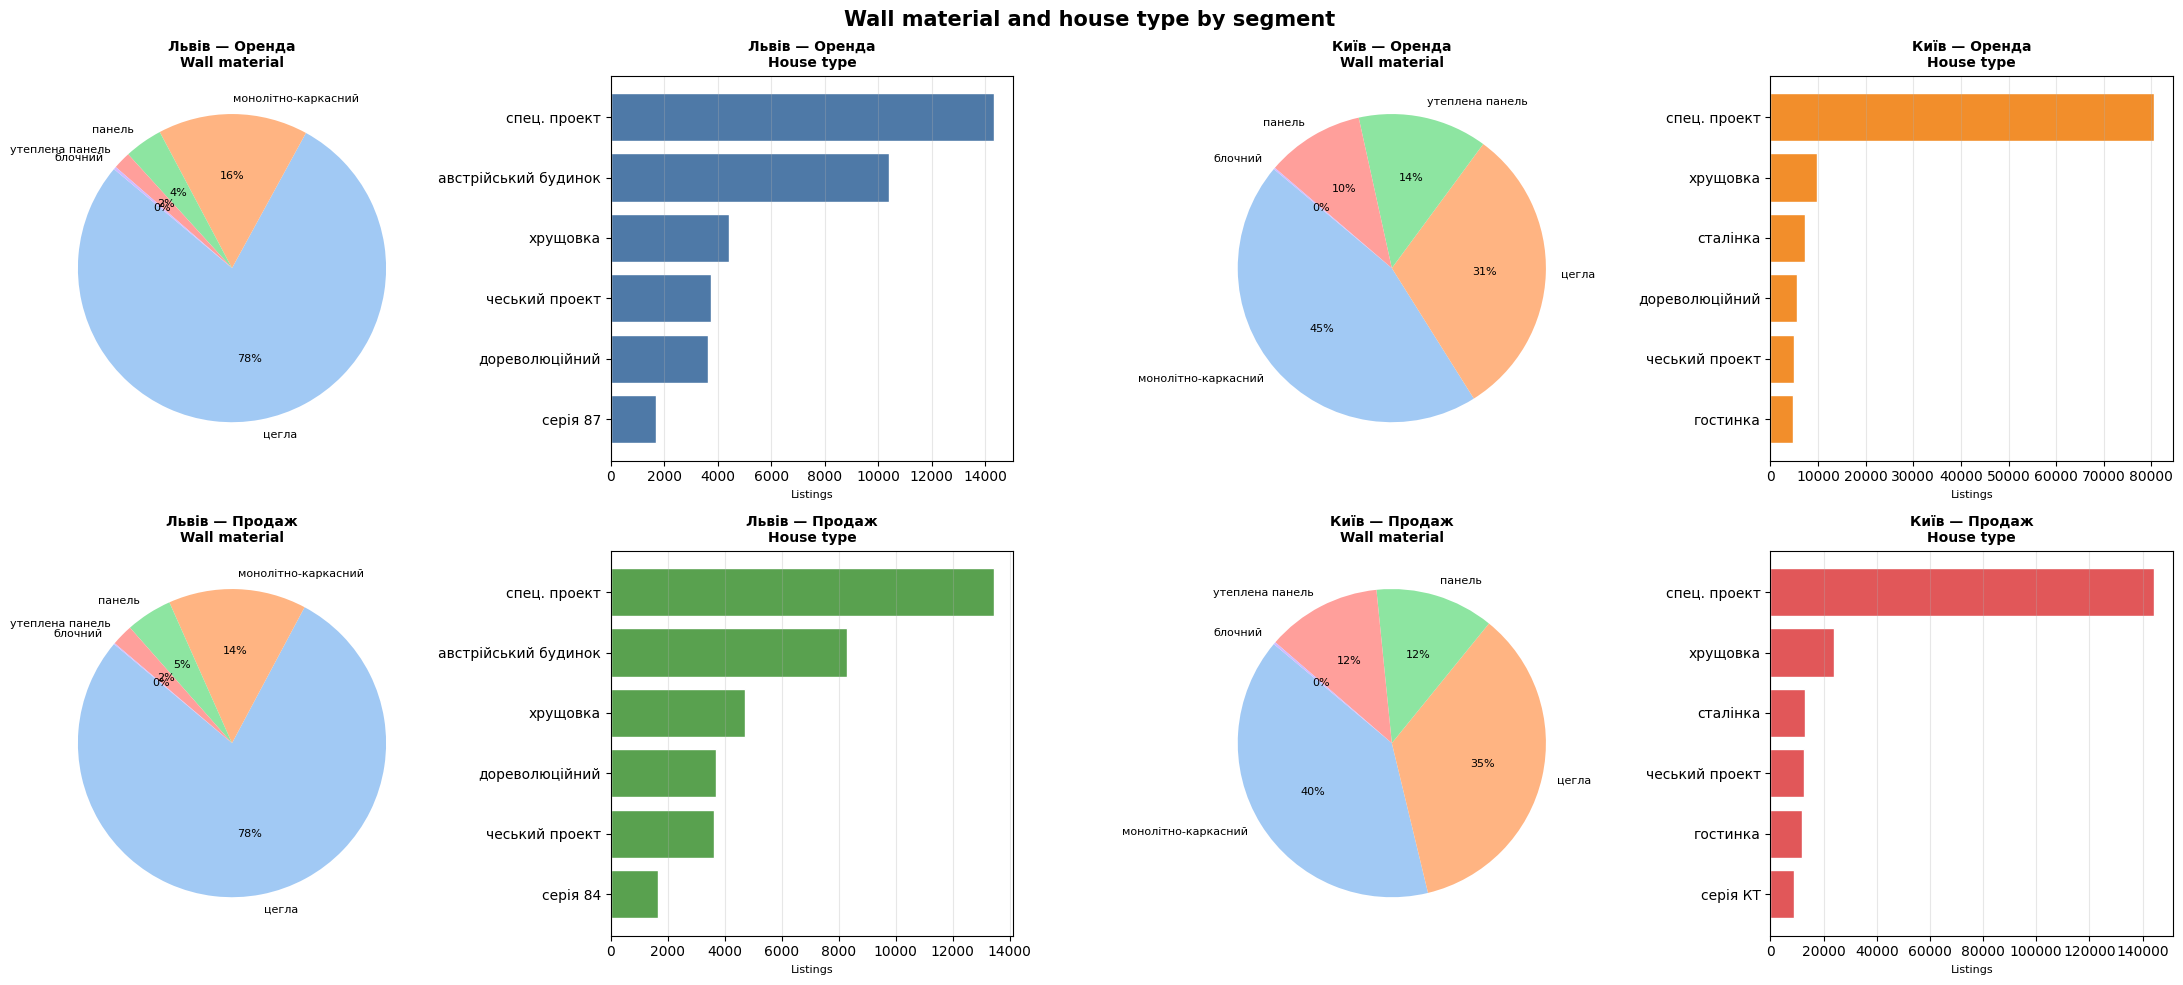

In [15]:
# ── Wall material and house type (4 segments) ──────────────
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.suptitle('Wall material and house type by segment', fontsize=15, fontweight='bold')

for i, (city, ctype, df_s) in enumerate(SEGS):
    # Left column: wall material (pie)
    ax_pie = axes[i // 2][( i % 2) * 2]
    # Right column: house type (bar)
    ax_bar = axes[i // 2][(i % 2) * 2 + 1]

    title = f'{city} — {ctype}'

    if 'wall_type' in df_s.columns:
        wall = df_s['wall_type'].value_counts().head(6)
        ax_pie.pie(wall.values, labels=wall.index, autopct='%1.0f%%',
                   startangle=140, colors=sns.color_palette('pastel', len(wall)),
                   textprops={'fontsize': 8})
        ax_pie.set_title(f'{title}\nWall material', fontsize=10, fontweight='bold')
    else:
        ax_pie.text(0.5, 0.5, 'wall_type\nN/A', ha='center', va='center',
                    transform=ax_pie.transAxes)
        ax_pie.set_title(title, fontsize=10)

    if 'house_type' in df_s.columns:
        house = df_s['house_type'].value_counts().head(6)
        ax_bar.barh(house.index[::-1], house.values[::-1],
                    color=SEG_COLORS[i], edgecolor='white')
        ax_bar.set_title(f'{title}\nHouse type', fontsize=10, fontweight='bold')
        ax_bar.set_xlabel('Listings', fontsize=8)
        ax_bar.grid(True, axis='x', alpha=0.3)
    else:
        ax_bar.text(0.5, 0.5, 'house_type\nN/A', ha='center', va='center',
                    transform=ax_bar.transAxes)

plt.tight_layout()
plt.savefig('wall_house_4seg.png', dpi=150)
plt.show()


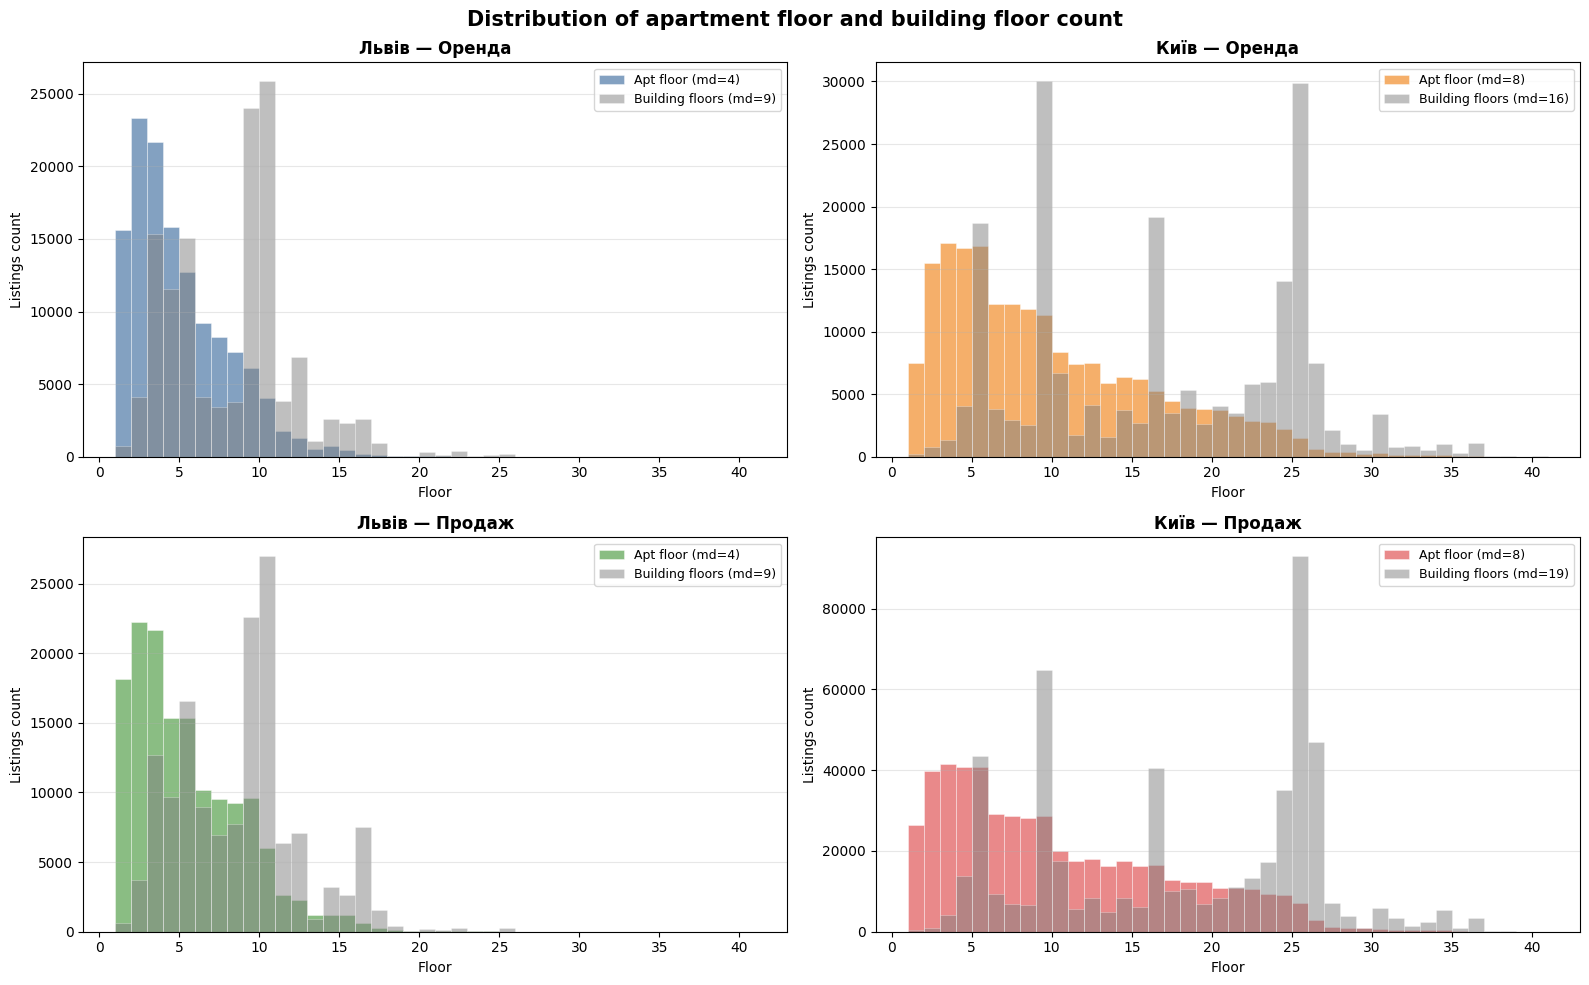


Segment                       Median floor        Median floors
---------------------------------------------------------------
  Львів — Оренда                   4.0                 9.0
  Київ — Оренда                   8.0                16.0
  Львів — Продаж                   4.0                 9.0
  Київ — Продаж                   8.0                19.0


In [16]:
# ── Floor distribution (4 segments) ────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Distribution of apartment floor and building floor count', fontsize=15, fontweight='bold')
axes_flat = axes.flatten()

for i, (city, ctype, df_s) in enumerate(SEGS):
    ax = axes_flat[i]

    floor_ok  = pd.to_numeric(df_s['floor'], errors='coerce').dropna()
    fcount_ok = (pd.to_numeric(df_s['floor_count'], errors='coerce').dropna()
                 if 'floor_count' in df_s.columns else pd.Series([], dtype=float))

    floor_ok  = floor_ok[(floor_ok > 0)  & (floor_ok  <= 40)]
    fcount_ok = fcount_ok[(fcount_ok > 0) & (fcount_ok <= 40)]

    bins = range(1, 42)

    if len(floor_ok) > 10:
        ax.hist(floor_ok,  bins=bins, alpha=0.7, color=SEG_COLORS[i],
                edgecolor='white', linewidth=0.4,
                label=f'Apt floor (md={floor_ok.median():.0f})')
    if len(fcount_ok) > 10:
        ax.hist(fcount_ok, bins=bins, alpha=0.5, color='gray',
                edgecolor='white', linewidth=0.4,
                label=f'Building floors (md={fcount_ok.median():.0f})')

    ax.set_title(f'{city} — {ctype}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Floor', fontsize=10)
    ax.set_ylabel('Listings count', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('floor_dist_4seg.png', dpi=150)
plt.show()

# Summary table
print(f"\n{'Segment':<25} {'Median floor':>16} {'Median floors':>20}")
print("-" * 63)
for city, ctype, df_s in SEGS:
    f  = pd.to_numeric(df_s['floor'], errors='coerce').median()
    fc = (pd.to_numeric(df_s['floor_count'], errors='coerce').median()
          if 'floor_count' in df_s.columns else float('nan'))
    print(f"  {city} — {ctype:<12}  {f:>14.1f}  {fc:>18.1f}")


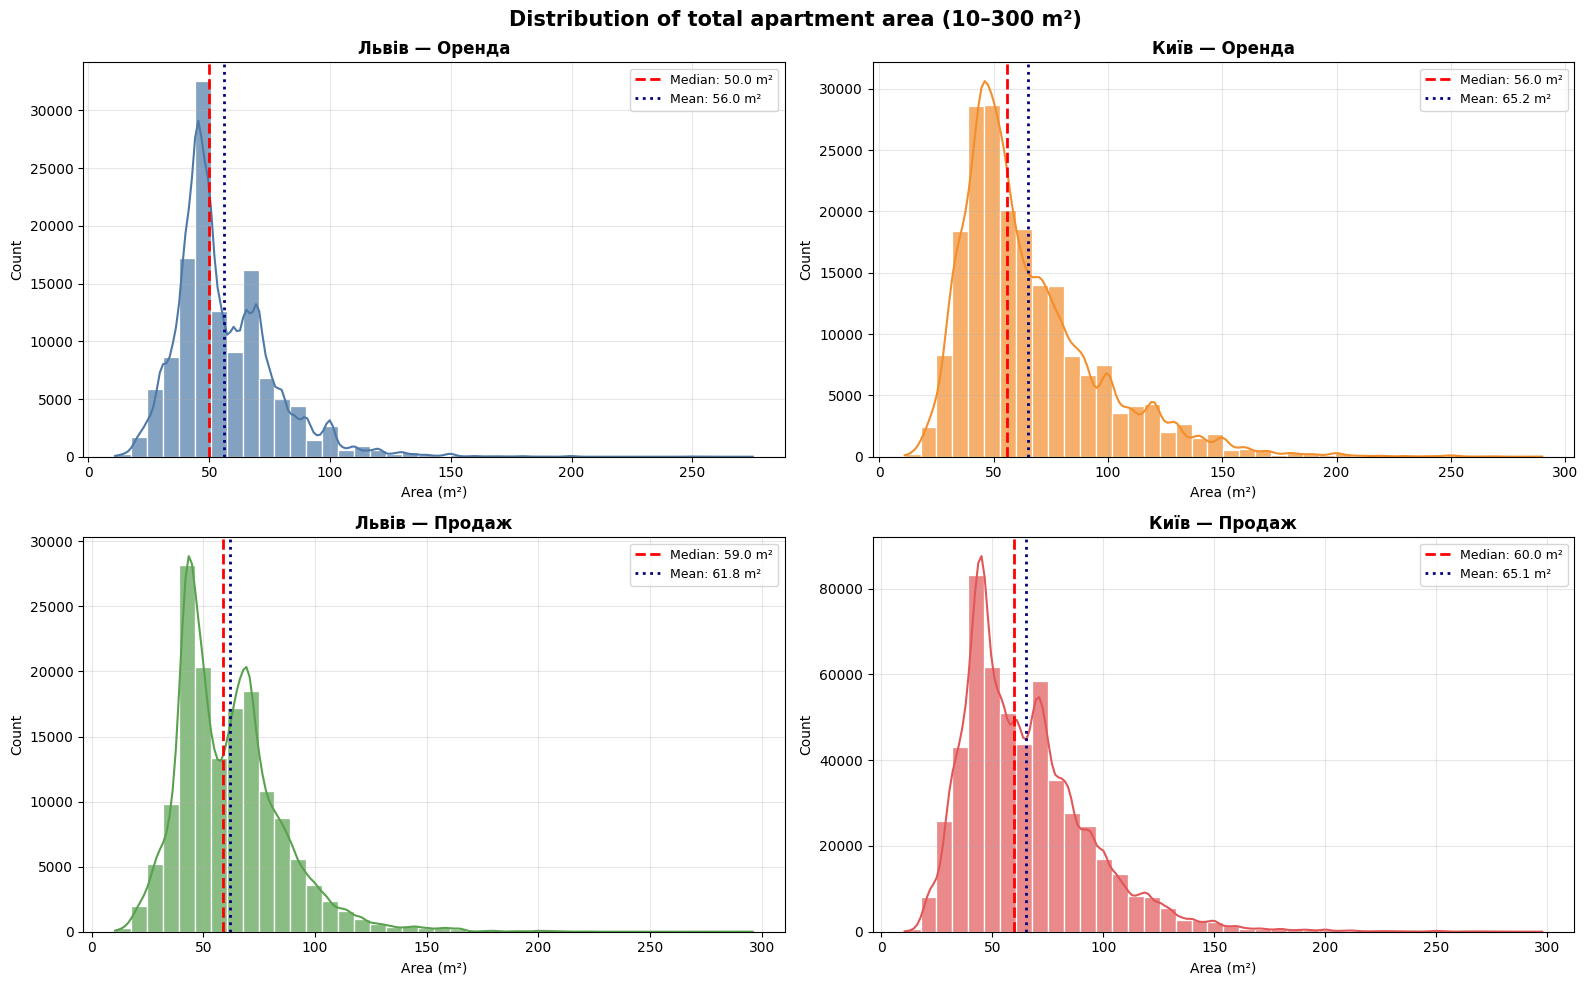

In [17]:
# ── Apartment area distribution (4 segments) ────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Distribution of total apartment area (10–300 m²)', fontsize=15, fontweight='bold')
axes_flat = axes.flatten()

for i, (city, ctype, df_s) in enumerate(SEGS):
    ax = axes_flat[i]

    area = pd.to_numeric(df_s['area_total'], errors='coerce')
    area = area[(area > 10) & (area < 300)].dropna()

    if len(area) < 10:
        ax.text(0.5, 0.5, 'Not enough data', ha='center', va='center',
                transform=ax.transAxes)
        ax.set_title(f'{city} — {ctype}')
        continue

    median_val = area.median()
    mean_val   = area.mean()

    sns.histplot(area, bins=40, kde=True, ax=ax,
                 color=SEG_COLORS[i], edgecolor='white', alpha=0.7)
    ax.axvline(median_val, color='red',  linestyle='--', linewidth=2,
               label=f'Median: {median_val:.1f} m²')
    ax.axvline(mean_val,   color='navy', linestyle=':',  linewidth=2,
               label=f'Mean: {mean_val:.1f} m²')

    ax.set_title(f'{city} — {ctype}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Area (m²)', fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('area_dist_4seg.png', dpi=150)
plt.show()


## 3. Missing Data Profiling

We visualise the fraction of NaN per column separately for rent and sale.
Columns with > 50% missing are candidates to exclude from the model.


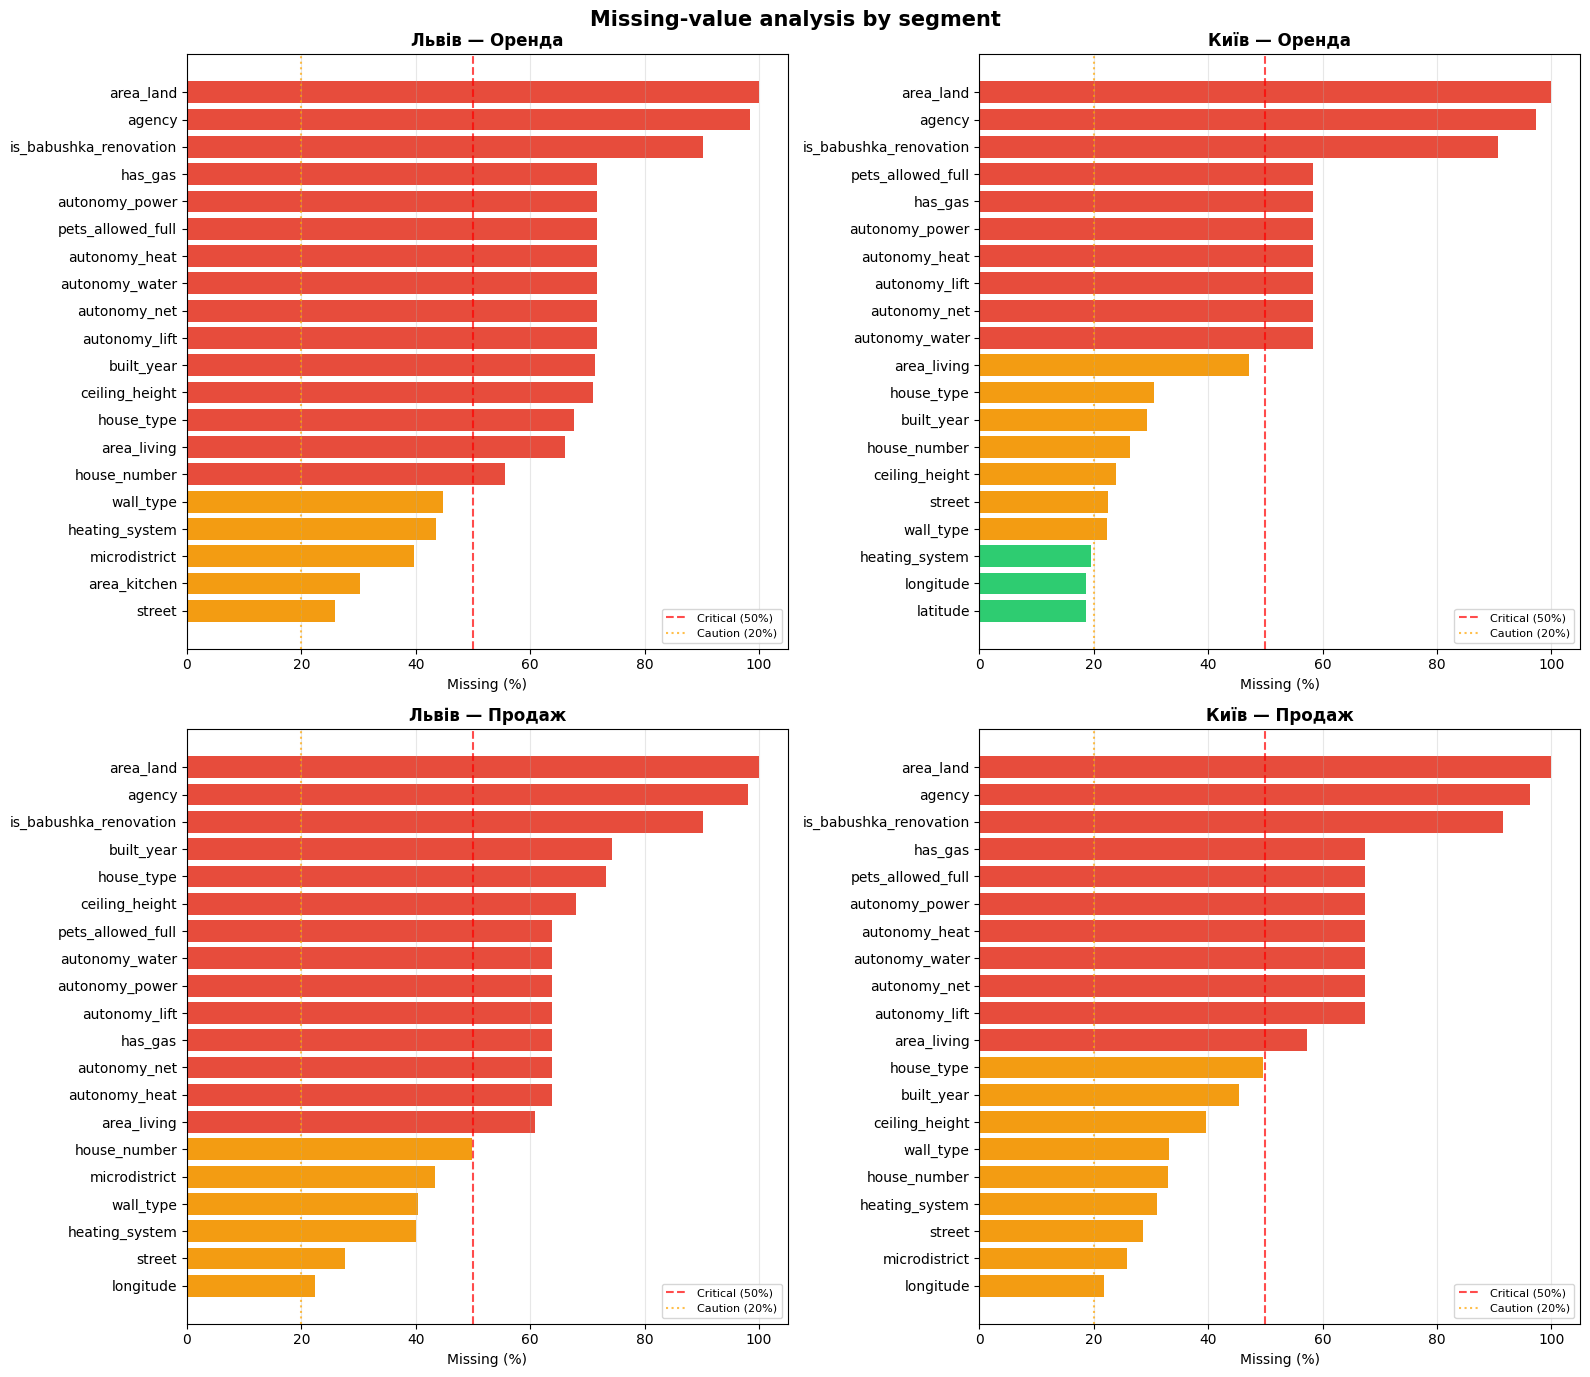


Columns with >30% missing (any segment):
  Львів — Оренда: ['microdistrict', 'house_number', 'area_living', 'area_kitchen', 'area_land', 'built_year', 'ceiling_height', 'wall_type', 'house_type', 'heating_system', 'agency', 'has_gas', 'autonomy_power', 'autonomy_heat', 'autonomy_water', 'autonomy_net', 'autonomy_lift', 'is_babushka_renovation', 'pets_allowed_full']
  Київ — Оренда: ['area_living', 'area_land', 'house_type', 'agency', 'has_gas', 'autonomy_power', 'autonomy_heat', 'autonomy_water', 'autonomy_net', 'autonomy_lift', 'is_babushka_renovation', 'pets_allowed_full']
  Львів — Продаж: ['microdistrict', 'house_number', 'area_living', 'area_land', 'built_year', 'ceiling_height', 'wall_type', 'house_type', 'heating_system', 'agency', 'has_gas', 'autonomy_power', 'autonomy_heat', 'autonomy_water', 'autonomy_net', 'autonomy_lift', 'is_babushka_renovation', 'pets_allowed_full']
  Київ — Продаж: ['house_number', 'area_living', 'area_land', 'built_year', 'ceiling_height', 'wall_type',

In [18]:
# ── Missing-value analysis (4 segments) ─────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle('Missing-value analysis by segment', fontsize=15, fontweight='bold')
axes_flat = axes.flatten()

for i, (city, ctype, df_s) in enumerate(SEGS):
    ax = axes_flat[i]

    missing = (df_s.isnull().sum() / len(df_s) * 100)
    missing = missing[missing > 0].sort_values(ascending=False).head(20)

    if missing.empty:
        ax.text(0.5, 0.5, 'No missing values', ha='center', va='center',
                transform=ax.transAxes, fontsize=12)
        ax.set_title(f'{city} — {ctype}', fontsize=12, fontweight='bold')
        continue

    colors_bar = [('#e74c3c' if v > 50 else '#f39c12' if v > 20 else '#2ecc71')
                  for v in missing.values]
    ax.barh(missing.index[::-1], missing.values[::-1], color=colors_bar[::-1])
    ax.axvline(50, color='red',    linestyle='--', alpha=0.7, label='Critical (50%)')
    ax.axvline(20, color='orange', linestyle=':',  alpha=0.7, label='Caution (20%)')
    ax.set_title(f'{city} — {ctype}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Missing (%)', fontsize=10)
    ax.grid(True, axis='x', alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('missing_4seg.png', dpi=150)
plt.show()

# Table: columns with >30% missing
print("\nColumns with >30% missing (any segment):")
critical_cols = set()
for city, ctype, df_s in SEGS:
    bad = df_s.isnull().mean()[lambda x: x > 0.30].index.tolist()
    if bad:
        print(f"  {city} — {ctype}: {bad}")
        critical_cols.update(bad)
if not critical_cols:
    print("  No critical missing values ✅")


## 4. Duplicate Diagnostics

**Methodology:**
A duplicate ≠ just identical rows. In real-estate aggregators, a single listing:
- may be posted on multiple sites (cross-site duplicate)
- may be updated monthly across several months (repeat snapshot)

Therefore, we first **diagnose** the nature of the duplicates.


In [19]:
# Count parameter combinations that should be unique
potential_duplicates = data.groupby(['latitude', 'longitude', 'area_total', 'floor']).size().reset_index(name='count')
duplicates_found = potential_duplicates[potential_duplicates['count'] > 1]

print(f"Likely duplicates found: {duplicates_found.shape[0]}")
print(f"Share {duplicates_found.shape[0]/data.shape[0]*100}% ")

Likely duplicates found: 154989
Share 15.253066329960033% 


In [20]:
# Define the key uniqueness fields for an object
identity_cols = ['latitude', 'longitude', 'area_total', 'floor']

# Extract all rows that have 'twins'
duplicates_df = data[data.duplicated(subset=identity_cols, keep=False)].sort_values(by=identity_cols + ['date'])
columns_to_show = [
    'date', 'contract_type', 'realty_type', 'region', 'city',
    'district', 'street', 'house_number', 'latitude', 'longitude',
    'price', 'area_total', 'floor','site'
]

# Show result (.head(20) to avoid memory issues if there are many)
duplicates_df[columns_to_show].head(100)

,date,contract_type,realty_type,region,city,district,street,house_number,latitude,longitude,price,area_total,floor,site
145684,2025-06-24,Продаж,Квартира,Київська,Київ,NaN,NaN,NaN,46.429527,30.765610,150000.0,90.0,9.0,rieltor.ua
224444,2025-09-24,Продаж,Квартира,Київська,Київ,Голосіївський,NaN,5/3,46.429527,30.765610,150000.0,90.0,9.0,rieltor.ua
282594,2025-11-24,Продаж,Квартира,Київська,Київ,NaN,NaN,NaN,46.433132,30.761843,400000.0,204.0,3.0,rieltor.ua
310425,2025-12-24,Продаж,Квартира,Київська,Київ,NaN,NaN,NaN,46.433132,30.761843,400000.0,204.0,3.0,rieltor.ua
145744,2025-06-24,Продаж,Квартира,Київська,Київ,NaN,NaN,NaN,46.433132,30.761843,400000.0,204.0,3.0,rieltor.ua
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133588,2025-06-24,Продаж,Квартира,Львівська,Львів,Залізничний,вул. Стрийська,121б,49.774292,24.022153,69850.0,64.0,5.0,olx.ua
622630,2024-06-24,Продаж,Квартира,Львівська,Львів,Франківський,вул. Стрийська,121б,49.774292,24.022153,121752.0,68.4,1.0,dom.ria.com
651501,2024-07-24,Продаж,Квартира,Львівська,Львів,Франківський,вул. Стрийська,121б,49.774292,24.022153,121752.0,68.4,1.0,dom.ria.com
680372,2024-08-24,Продаж,Квартира,Львівська,Львів,Франківський,вул. Стрийська,121б,49.774292,24.022153,121752.0,68.4,1.0,dom.ria.com


In [21]:
def diagnose_duplicates(data):
    identity_cols = ['latitude', 'longitude', 'area_total', 'floor', 'contract_type']
    dup_mask = data.duplicated(subset=identity_cols, keep=False)
    dups = data[dup_mask].copy()
    print(f"Rows with potential duplicates: {len(dups):,} ({100*len(dups)/len(data):.1f}%)")

    cross_site = dups.groupby(identity_cols)['site'].nunique().reset_index(name='n_sites')
    cross = cross_site[cross_site['n_sites'] > 1]
    print(f"\nGroups on multiple sites (true duplicates): {len(cross):,}")

    time_spread = (
        dups.groupby(identity_cols)['date']
        .agg(min_date='min', max_date='max', n_dates='nunique')
        .reset_index()
    )
    time_spread['days_span'] = (time_spread['max_date'] - time_spread['min_date']).dt.days
    print(f"Groups with >180-day spread (separate events): {(time_spread['days_span']>180).sum():,}")
    print(f"Groups with ≤30-day spread (cross-site):    {(time_spread['days_span']<=30).sum():,}")

    group_sizes = data.groupby(identity_cols).size().reset_index(name='count')
    print("\nCopies-per-group distribution:")
    print(group_sizes['count'].value_counts().head(10))
    return time_spread, group_sizes

time_spread, group_sizes = diagnose_duplicates(data)

Rows with potential duplicates: 773,284 (76.1%)

Groups on multiple sites (true duplicates): 34,561
Groups with >180-day spread (separate events): 30,850
Groups with ≤30-day spread (cross-site):    32,709

Copies-per-group distribution:
count
1     234197
2      72489
3      33588
4      18449
5      10045
6       6404
7       3914
8       2731
9       2034
10      1434
Name: count, dtype: int64


 gap_days  removed  remaining  pct_removed
       14    25125     990992     2.472648
       30   169952     846165    16.725633
       60   330772     685345    32.552551
       90   363700     652417    35.793122
      120   374822     641295    36.887681
      180   385533     630584    37.941792
      365   396082     620035    38.979960


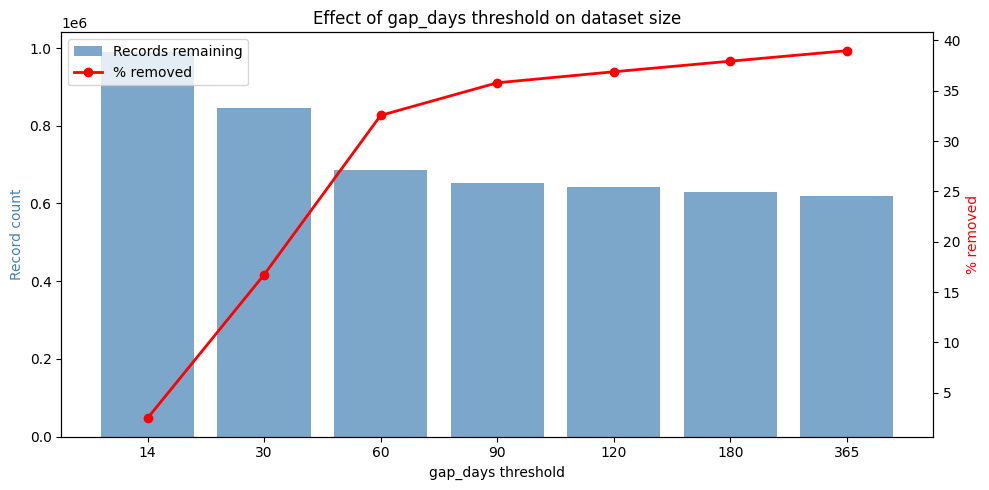

In [22]:
def compare_gap_strategies(data):
    identity_cols = ['latitude', 'longitude', 'area_total', 'floor', 'contract_type']
    data = data.sort_values('date').reset_index(drop=True)
    data['_prev_date'] = data.groupby(identity_cols)['date'].shift(1)
    data['_days_since_prev'] = (data['date'] - data['_prev_date']).dt.days

    gaps = [14, 30, 60, 90, 120, 180, 365]
    results = []
    for gap in gaps:
        n_removed = (data['_prev_date'].notna() & (data['_days_since_prev'] <= gap)).sum()
        results.append({'gap_days': gap, 'removed': n_removed,
                        'remaining': len(data) - n_removed,
                        'pct_removed': 100 * n_removed / len(data)})
    results_df = pd.DataFrame(results)
    print(results_df.to_string(index=False))

    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax2 = ax1.twinx()
    ax1.bar(results_df['gap_days'].astype(str), results_df['remaining'],
            color='steelblue', alpha=0.7, label='Records remaining')
    ax2.plot(results_df['gap_days'].astype(str), results_df['pct_removed'],
             color='red', marker='o', linewidth=2, label='% removed')
    ax1.set_xlabel('gap_days threshold')
    ax1.set_ylabel('Record count', color='steelblue')
    ax2.set_ylabel('% removed', color='red')
    ax1.set_title('Effect of gap_days threshold on dataset size')
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
    plt.tight_layout()
    plt.savefig('dedup_strategy_comparison.png', dpi=150)
    plt.show()
    return results_df

gap_results = compare_gap_strategies(data)

## 5. Deduplication (time-dependent)

**Conclusion from diagnostics:**
- Optimal threshold: **sale = 120 days**, **rent = 45 days**
- Median change after dedup: sale **1.3%**, rent **5.3%** (within tolerance)
- Final dataset: **653,047 rows**


In [23]:
# ─────────────────────────────────────────────────────────────
# DEDUPLICATION — 1 record per object per month
#
# Logic:
#   Same flat in different months = different observations (price dynamics) → keep
#   Same flat multiple times in one month = bumping → keep ONLY the LAST record
#
# Identifying the 'same object' — 2 levels:
#   Level 1 (has coordinates): latitude + longitude + area_total + floor + contract_type
#   Level 2 (no coordinates): city + district + street + house_number + area_total + floor + contract_type
# ─────────────────────────────────────────────────────────────

ID_GEO  = ['latitude', 'longitude', 'area_total', 'floor', 'contract_type']
ID_ADDR = ['city', 'district', 'street', 'house_number', 'area_total', 'floor', 'contract_type']


def deduplicate_monthly(df, label=''):
    """
    For each unique object and month, keeps only the latest record.
    Rows without enough identifiers — left untouched.
    """
    n_before = len(df)
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df['_year_month'] = df['date'].dt.to_period('M')

    has_geo  = df['latitude'].notna() & df['longitude'].notna()
    df_geo   = df[has_geo].copy()
    df_addr  = df[~has_geo].copy()

    def keep_last(d, id_cols):
        available = [c for c in id_cols if c in d.columns]
        if len(available) < len(id_cols) or len(d) == 0:
            return d
        # Rows with all id columns → dedup
        has_id     = d[available].notna().all(axis=1)
        d_with_id  = d[has_id].copy()
        d_no_id    = d[~has_id].copy()

        group_cols = available + ['_year_month']
        # Last record in month = max date
        d_deduped = (d_with_id
                     .sort_values('date')
                     .groupby(group_cols, as_index=False)
                     .last())
        return pd.concat([d_deduped, d_no_id], ignore_index=True)

    df_geo_dd  = keep_last(df_geo,  ID_GEO)
    df_addr_dd = keep_last(df_addr, ID_ADDR)

    df_clean = (pd.concat([df_geo_dd, df_addr_dd], ignore_index=True)
                .drop(columns=['_year_month'])
                .sort_values('date')
                .reset_index(drop=True))

    n_removed = n_before - len(df_clean)
    geo_rm    = len(df_geo)  - len(df_geo_dd)
    addr_rm   = len(df_addr) - len(df_addr_dd)

    print(f"\n  ┌─ {label}")
    print(f"  │  Rows before:     {n_before:>8,}")
    print(f"  │  With coords:     {len(df_geo):>8,}  →  removed (geo):  {geo_rm:,}")
    print(f"  │  Without coords:  {len(df_addr):>8,}  →  removed (addr): {addr_rm:,}")
    print(f"  │  Total removed:   {n_removed:>8,}  ({100*n_removed/n_before:.1f}%)")
    print(f"  └─ Remaining:       {len(df_clean):>8,}")
    return df_clean


print("=" * 55)
print("DEDUPLICATION — 1 record per object per month")
print("=" * 55)

df_rent_lviv_clean = deduplicate_monthly(df_rent_lviv, label='Lviv — Rent')
df_rent_kyiv_clean = deduplicate_monthly(df_rent_kyiv, label='Kyiv  — Rent')
df_sale_lviv_clean = deduplicate_monthly(df_sale_lviv, label='Lviv — Sale')
df_sale_kyiv_clean = deduplicate_monthly(df_sale_kyiv, label='Kyiv  — Sale')

total_after  = sum(len(d) for d in [df_rent_lviv_clean, df_rent_kyiv_clean,
                                     df_sale_lviv_clean, df_sale_kyiv_clean])
total_before = len(data)
print(f"\n{'='*55}")
print(f"SUMMARY: {total_after:,} rows  (was {total_before:,}, removed {total_before-total_after:,} = {100*(total_before-total_after)/total_before:.1f}%)")
print(f"{'='*55}")


DEDUPLICATION — 1 record per object per month

  ┌─ Lviv — Rent
  │  Rows before:      133,766
  │  With coords:      100,974  →  removed (geo):  5,475
  │  Without coords:    32,792  →  removed (addr): 0
  │  Total removed:      5,475  (4.1%)
  └─ Remaining:        128,291

  ┌─ Kyiv  — Rent
  │  Rows before:      199,152
  │  With coords:      162,038  →  removed (geo):  4,117
  │  Without coords:    37,114  →  removed (addr): 0
  │  Total removed:      4,117  (2.1%)
  └─ Remaining:        195,035

  ┌─ Lviv — Sale
  │  Rows before:      153,500
  │  With coords:      119,080  →  removed (geo):  6,759
  │  Without coords:    34,420  →  removed (addr): 4
  │  Total removed:      6,763  (4.4%)
  └─ Remaining:        146,737

  ┌─ Kyiv  — Sale
  │  Rows before:      529,699
  │  With coords:      414,213  →  removed (geo):  23,067
  │  Without coords:   115,486  →  removed (addr): 4
  │  Total removed:     23,071  (4.4%)
  └─ Remaining:        506,628

SUMMARY: 976,691 rows  (was 1,016,

Segment                 Median before   Median after       Δ%       OK?
────────────────────────────────────────────────────────────────────
  Львів — Оренда                 337             335      0.5%  ✅
  Київ — Оренда                 379             378      0.3%  ✅
  Львів — Продаж               1,382           1,383      0.1%  ✅
  Київ — Продаж               1,500           1,500      0.0%  ✅


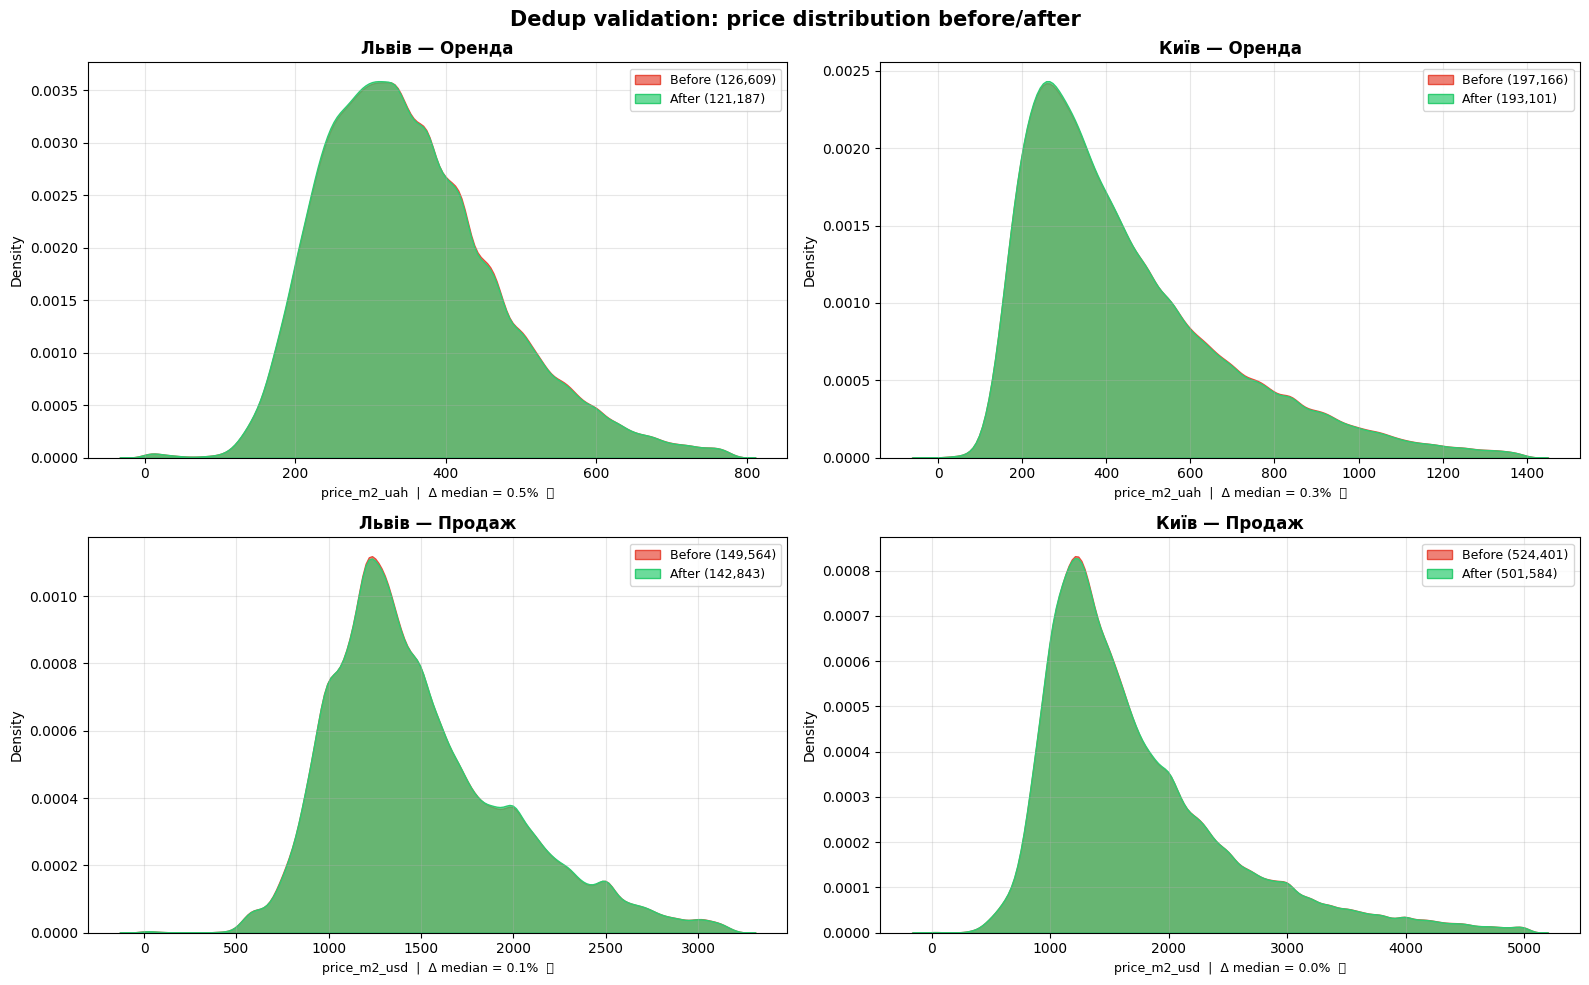

In [24]:
# ── Dedup validation — price distribution before/after (4 segments) ─
CLEAN_MAP = {
    ('Львів', 'Оренда'): (df_rent_lviv, df_rent_lviv_clean),
    ('Київ',  'Оренда'): (df_rent_kyiv, df_rent_kyiv_clean),
    ('Львів', 'Продаж'): (df_sale_lviv, df_sale_lviv_clean),
    ('Київ',  'Продаж'): (df_sale_kyiv, df_sale_kyiv_clean),
}

PRICE_FOR_VALID = {
    ('Львів', 'Оренда'): 'price_m2_uah',
    ('Київ',  'Оренда'): 'price_m2_uah',
    ('Львів', 'Продаж'): 'price_m2_usd',
    ('Київ',  'Продаж'): 'price_m2_usd',
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Dedup validation: price distribution before/after', fontsize=15, fontweight='bold')
axes_flat = axes.flatten()

print(f"{'Segment':<22} {'Median before':>14} {'Median after':>14} {'Δ%':>8}  {'OK?':>8}")
print("─" * 68)

for i, ((city, ctype), (df_before, df_after)) in enumerate(CLEAN_MAP.items()):
    ax = axes_flat[i]
    col = PRICE_FOR_VALID[(city, ctype)]

    if col not in df_before.columns:
        ax.text(0.5, 0.5, f'{col}\nN/A', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'{city} — {ctype}')
        continue

    p99   = df_before[col].quantile(0.99)
    orig  = pd.to_numeric(df_before[col], errors='coerce').dropna()
    clean = pd.to_numeric(df_after[col],  errors='coerce').dropna()
    orig  = orig[orig  <= p99]
    clean = clean[clean <= p99]

    sns.kdeplot(orig,  ax=ax, label=f'Before ({len(orig):,})',    color='#e74c3c', alpha=0.7, fill=True)
    sns.kdeplot(clean, ax=ax, label=f'After ({len(clean):,})', color='#2ecc71', alpha=0.7, fill=True)

    med_before = orig.median()
    med_after  = clean.median()
    delta_pct  = abs(med_before - med_after) / med_before * 100
    ok = '✅' if delta_pct < 5 else '⚠️'

    ax.set_title(f'{city} — {ctype}', fontsize=12, fontweight='bold')
    ax.set_xlabel(f'{col}  |  Δ median = {delta_pct:.1f}%  {ok}', fontsize=9)
    ax.set_ylabel('Density', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    print(f"  {city} — {ctype:<12}  {med_before:>12,.0f}  {med_after:>14,.0f}  {delta_pct:>7.1f}%  {ok}")

plt.tight_layout()
plt.savefig('dedup_validation_4seg.png', dpi=150)
plt.show()


## 6. Physical anomaly filter

Remove unrealistic values (parsing errors or fraudulent listings).


In [25]:
# ─────────────────────────────────────────────────────────────
# PHYSICAL ANOMALY FILTER — 4 datasets separately
# (no price filters — only physical parameters)
# ─────────────────────────────────────────────────────────────

FILTERS_COMMON = {
    'area_total':  (10, 400),
    'floor':       (1,  50),
    'floor_count': (1,  50),
    'room_count':  (1,  10),
}

def filter_anomalies(df, contract_type, label=''):
    mask     = pd.Series(True, index=df.index)
    n_before = len(df)
    removed_by_col = {}

    for col, (lo, hi) in FILTERS_COMMON.items():
        if col not in df.columns:
            continue
        col_num  = pd.to_numeric(df[col], errors='coerce')
        col_mask = col_num.between(lo, hi) | col_num.isna()
        n_rm     = (~col_mask).sum()
        if n_rm > 0:
            removed_by_col[col] = n_rm
        mask &= col_mask

    df_out    = df[mask].copy().reset_index(drop=True)
    n_removed = n_before - len(df_out)

    print(f"\n  ┌─ {label}")
    for col, n in removed_by_col.items():
        lo, hi = FILTERS_COMMON[col]
        print(f"  │  {col:<18} outside [{lo:>3}, {hi:>3}] → removed {n:,}")
    print(f"  │  Total removed: {n_removed:,}  ({100*n_removed/n_before:.1f}%)")
    print(f"  └─ Remaining:     {len(df_out):,}")
    return df_out


print("=" * 55)
print("PHYSICAL ANOMALY FILTER")
print("=" * 55)

df_rent_lviv_clean = filter_anomalies(df_rent_lviv_clean, 'Оренда', 'Lviv — Rent')
df_rent_kyiv_clean = filter_anomalies(df_rent_kyiv_clean, 'Оренда', 'Kyiv  — Rent')
df_sale_lviv_clean = filter_anomalies(df_sale_lviv_clean, 'Продаж', 'Lviv — Sale')
df_sale_kyiv_clean = filter_anomalies(df_sale_kyiv_clean, 'Продаж', 'Kyiv  — Sale')

total = sum(len(d) for d in [df_rent_lviv_clean, df_rent_kyiv_clean,
                               df_sale_lviv_clean, df_sale_kyiv_clean])
print(f"\n{'='*55}")
print(f"SUMMARY: {total:,} rows across 4 datasets")
print(f"{'='*55}")


PHYSICAL ANOMALY FILTER

  ┌─ Lviv — Rent
  │  area_total         outside [ 10, 400] → removed 129
  │  floor              outside [  1,  50] → removed 6
  │  floor_count        outside [  1,  50] → removed 10
  │  Total removed: 141  (0.1%)
  └─ Remaining:     128,150

  ┌─ Kyiv  — Rent
  │  area_total         outside [ 10, 400] → removed 48
  │  floor              outside [  1,  50] → removed 3
  │  floor_count        outside [  1,  50] → removed 8
  │  Total removed: 58  (0.0%)
  └─ Remaining:     194,977

  ┌─ Lviv — Sale
  │  area_total         outside [ 10, 400] → removed 69
  │  floor              outside [  1,  50] → removed 1
  │  floor_count        outside [  1,  50] → removed 7
  │  Total removed: 77  (0.1%)
  └─ Remaining:     146,660

  ┌─ Kyiv  — Sale
  │  area_total         outside [ 10, 400] → removed 165
  │  floor              outside [  1,  50] → removed 10
  │  floor_count        outside [  1,  50] → removed 45
  │  Total removed: 219  (0.0%)
  └─ Remaining:     506

## 6.1 Price outliers — quantile filtering

Without this step, RMSE in rent is ×9 of MAE — not the model's fault, it's typos/luxury in the tails. We clip [0.5%, 99.5%] per segment + hard-bounds as a safety net.


In [26]:
# ─────────────────────────────────────────────────────────────
# PRICE OUTLIER FILTER per segment — quantile clipping [0.5%, 99.5%]
# IMPORTANT: quantiles are computed ONLY on train (date ≤ TRAIN_END).
# Bounds are then applied to all rows (eliminates test leakage).
# ─────────────────────────────────────────────────────────────

TRAIN_END = pd.Timestamp('2025-04-30')

PRICE_BOUNDS = {
    'Оренда':  (0.005, 0.995),
    'Продаж':  (0.005, 0.995),
}
HARD_BOUNDS = {
    'price_uah':    (3_000, 500_000),   # UAH/mo
    'price_m2_usd': (150,   7_500),     # USD per m²
}

def filter_price_outliers(df, contract_type, label=''):
    """Quantiles from train; bounds applied to entire df."""
    df = df.copy()
    n0 = len(df)
    price_col = 'price_m2_usd' if contract_type == 'Продаж' else 'price_uah'
    if price_col not in df.columns:
        print(f'  [{label}] skipped: no {price_col}')
        return df
    p = pd.to_numeric(df[price_col], errors='coerce')
    train_mask = pd.to_datetime(df['date'], errors='coerce') <= TRAIN_END
    p_train = p[train_mask].dropna()
    lo_q, hi_q = PRICE_BOUNDS[contract_type]
    q_lo, q_hi = p_train.quantile([lo_q, hi_q]).values if len(p_train) >= 100 else p.quantile([lo_q, hi_q]).values
    hb_lo, hb_hi = HARD_BOUNDS[price_col]
    lo, hi = max(q_lo, hb_lo), min(q_hi, hb_hi)
    mask = p.between(lo, hi)
    df_out = df[mask].reset_index(drop=True)
    print(f'  [{label}] {price_col}: [{lo:,.0f}, {hi:,.0f}]  '
          f'removed {n0-len(df_out):,} ({100*(n0-len(df_out))/n0:.1f}%)  '
          f'remaining {len(df_out):,}')
    return df_out

print('=' * 60)
print('PRICE OUTLIER FILTER — quantile clipping (train-only bounds)')
print('=' * 60)
df_rent_lviv_clean = filter_price_outliers(df_rent_lviv_clean, 'Оренда', 'Lviv — Rent')
df_rent_kyiv_clean = filter_price_outliers(df_rent_kyiv_clean, 'Оренда', 'Kyiv  — Rent')
df_sale_lviv_clean = filter_price_outliers(df_sale_lviv_clean, 'Продаж', 'Lviv — Sale')
df_sale_kyiv_clean = filter_price_outliers(df_sale_kyiv_clean, 'Продаж', 'Kyiv  — Sale')
print('\n✅ Price outliers removed (train-derived bounds, no leakage)')


PRICE OUTLIER FILTER — quantile clipping (train-only bounds)
  [Lviv — Rent] price_uah: [6,000, 62,918]  removed 1,204 (0.9%)  remaining 126,946
  [Kyiv  — Rent] price_uah: [5,000, 181,349]  removed 1,335 (0.7%)  remaining 193,642
  [Lviv — Sale] price_m2_usd: [574, 3,500]  removed 3,688 (2.5%)  remaining 142,972
  [Kyiv  — Sale] price_m2_usd: [545, 5,667]  removed 5,237 (1.0%)  remaining 501,172

✅ Price outliers removed (train-derived bounds, no leakage)


In [27]:
# ── Save cleaned segments ──────────────────────────────────────────────────
import pickle
_out = _DATA_DIR / 'clean_segments.pkl'
_clean = {
    ('Львів','Оренда'): df_rent_lviv_clean,
    ('Київ', 'Оренда'): df_rent_kyiv_clean,
    ('Львів','Продаж'): df_sale_lviv_clean,
    ('Київ', 'Продаж'): df_sale_kyiv_clean,
}
with open(_out, 'wb') as f: pickle.dump(_clean, f)
print(f'✅ Saved → {_out}')
for k,v in _clean.items(): print(f'  {k}: {len(v):,} rows')


✅ Saved → /Users/veronikacharnosh/Desktop/Thesis/thesis vs code/thesis_package/notebooks/notebooks_data/clean_segments.pkl
  ('Львів', 'Оренда'): 126,946 rows
  ('Київ', 'Оренда'): 193,642 rows
  ('Львів', 'Продаж'): 142,972 rows
  ('Київ', 'Продаж'): 501,172 rows
